# Phase 3 – Machine Learning Modeling (Predicting Daily PM2.5)

**Goal:** Apply ML methods to model daily PM2.5 in NYC using weather + traffic features (and simple time features).

## 1. Setup

In [7]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import matplotlib.pyplot as plt

## 2. Load Data

In [8]:
DATA_PATH = "../data/processed/nyc_air_weather_traffic_2023_daily.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df.head()

,date,pm25,temp_mean,humidity_mean,wind_speed_mean,precip_mm,traffic_volume,weekday,is_weekend,traffic_level
0,2023-01-07,5.355729,3.4,NaN,9.8,0.0,913,5,True,low
1,2023-01-08,5.494271,0.8,NaN,8.1,0.2,12987,6,True,high
2,2023-01-09,9.529444,3.2,NaN,9.4,0.3,15315,0,False,high
3,2023-01-10,10.504687,2.7,NaN,11.1,0.7,454,1,False,low
4,2023-01-14,4.040104,1.1,NaN,10.4,0.0,9767,5,True,low


## 3. Feature Engineering

- Drop `humidity_mean` (all missing).
- Add time features: month, day-of-year, sin/cos seasonality.
- Add lag features: previous day's PM2.5 (`pm25_lag1`) and previous day's traffic (`traffic_lag1`).

In [9]:
df = df.drop(columns=["humidity_mean"])

df["month"] = df["date"].dt.month
df["dayofyear"] = df["date"].dt.dayofyear

# seasonality encoding
df["doy_sin"] = np.sin(2*np.pi*df["dayofyear"]/365.0)
df["doy_cos"] = np.cos(2*np.pi*df["dayofyear"]/365.0)

# lag features (previous observed day)
df["pm25_lag1"] = df["pm25"].shift(1)
df["traffic_lag1"] = df["traffic_volume"].shift(1)

# first row loses lag values
df_ml = df.dropna().reset_index(drop=True)

df_ml[["date","pm25","pm25_lag1","traffic_volume","traffic_lag1"]].head()

,date,pm25,pm25_lag1,traffic_volume,traffic_lag1
0,2023-01-08,5.494271,5.355729,12987,913.0
1,2023-01-09,9.529444,5.494271,15315,12987.0
2,2023-01-10,10.504687,9.529444,454,15315.0
3,2023-01-14,4.040104,10.504687,9767,454.0
4,2023-02-04,3.738021,4.040104,862,9767.0


## 4. Train/Test Split (Time-based)

To avoid leakage, use the earliest portion for training and the most recent portion for testing.

In [10]:
target = "pm25"

feature_cols = [
    "temp_mean",
    "wind_speed_mean",
    "precip_mm",
    "traffic_volume",
    "weekday",
    "is_weekend",
    "traffic_level",
    "month",
    "dayofyear",
    "doy_sin",
    "doy_cos",
    "pm25_lag1",
    "traffic_lag1",
]

X = df_ml[feature_cols]
y = df_ml[target]

# 80/20 time split
split_idx = int(len(df_ml) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

df_ml.loc[split_idx, "date"], len(X_train), len(X_test)

(Timestamp('2023-10-16 00:00:00'), 135, 34)

## 5. Preprocessing

- Numeric features: impute (median), then scale for linear models.
- Categorical features: one-hot encode.

In [11]:
numeric_features = [
    "temp_mean", "wind_speed_mean", "precip_mm", "traffic_volume",
    "weekday", "month", "dayofyear", "doy_sin", "doy_cos",
    "pm25_lag1", "traffic_lag1"
]
categorical_features = ["is_weekend", "traffic_level"]

numeric_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transform = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transform, numeric_features),
        ("cat", categorical_transform, categorical_features),
    ],
    remainder="drop"
)

## 6. Baseline + Models

Models:
- Dummy baseline (predict training mean)
- Linear Regression
- Ridge / Lasso
- Random Forest
- Gradient Boosting

Evaluation: MAE, RMSE, R² on the held-out test set.

In [12]:
def eval_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

models = {}

models["DummyMean"] = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="mean"))
])

models["LinearRegression"] = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

models["Ridge"] = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0, random_state=42))
])

models["Lasso"] = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Lasso(alpha=0.01, random_state=42, max_iter=20000))
])

models["RandomForest"] = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ))
])

models["GradientBoosting"] = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

results = [eval_model(name, m, X_train, y_train, X_test, y_test) for name, m in models.items()]
res_df = pd.DataFrame(results).sort_values("RMSE")
res_df

,model,MAE,RMSE,R2
4,RandomForest,3.455867,4.477957,0.252293
5,GradientBoosting,3.355209,4.755317,0.156801
0,DummyMean,5.638073,6.324341,-0.491427
2,Ridge,7.136216,8.549363,-1.725454
3,Lasso,7.432219,8.799678,-1.887387
1,LinearRegression,7.855960,9.209301,-2.162458


## 7. Time-Series Cross-Validation for Hyperparameters

Use `TimeSeriesSplit` on the training portion to tune:
- Ridge alpha
- Lasso alpha
- RandomForest depth + min_samples_leaf
- GradientBoosting learning rate + n_estimators

Then re-evaluate tuned models on the held-out test set.

In [13]:
tscv = TimeSeriesSplit(n_splits=5)

tuned = {}

# Ridge
ridge_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", Ridge(random_state=42))])
ridge_grid = {"model__alpha": [0.1, 1.0, 10.0, 100.0]}
ridge_search = GridSearchCV(ridge_pipe, ridge_grid, cv=tscv, scoring="neg_root_mean_squared_error")
ridge_search.fit(X_train, y_train)
tuned["Ridge_tuned"] = ridge_search.best_estimator_
ridge_search.best_params_

{'model__alpha': 100.0}

In [14]:
# Lasso
lasso_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", Lasso(random_state=42, max_iter=50000))])
lasso_grid = {"model__alpha": [0.001, 0.01, 0.05, 0.1]}
lasso_search = GridSearchCV(lasso_pipe, lasso_grid, cv=tscv, scoring="neg_root_mean_squared_error")
lasso_search.fit(X_train, y_train)
tuned["Lasso_tuned"] = lasso_search.best_estimator_
lasso_search.best_params_

{'model__alpha': 0.1}

In [15]:
# Random Forest
rf_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))])
rf_grid = {
    "model__n_estimators": [300, 800],
    "model__max_depth": [None, 6, 12],
    "model__min_samples_leaf": [1, 2, 4],
}
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=tscv, scoring="neg_root_mean_squared_error")
rf_search.fit(X_train, y_train)
tuned["RandomForest_tuned"] = rf_search.best_estimator_
rf_search.best_params_

{'model__max_depth': None,
 'model__min_samples_leaf': 4,
 'model__n_estimators': 800}

In [16]:
# Gradient Boosting
gb_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", GradientBoostingRegressor(random_state=42))])
gb_grid = {
    "model__n_estimators": [200, 500],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3],
}
gb_search = GridSearchCV(gb_pipe, gb_grid, cv=tscv, scoring="neg_root_mean_squared_error")
gb_search.fit(X_train, y_train)
tuned["GradientBoosting_tuned"] = gb_search.best_estimator_
gb_search.best_params_

{'model__learning_rate': 0.03,
 'model__max_depth': 3,
 'model__n_estimators': 200}

In [17]:
tuned_results = [eval_model(name, m, X_train, y_train, X_test, y_test) for name, m in tuned.items()]
tuned_df = pd.DataFrame(tuned_results).sort_values("RMSE")
tuned_df

,model,MAE,RMSE,R2
2,RandomForest_tuned,3.418599,4.384423,0.283203
3,GradientBoosting_tuned,3.310599,4.489182,0.248540
0,Ridge_tuned,3.486167,4.818371,0.134291
1,Lasso_tuned,5.401569,6.850376,-0.749848


## 8. Best Model Diagnostics

Plot predictions vs actuals on the test period and show error distribution.

In [18]:
# pick best by RMSE among tuned + untuned
all_models = {**models, **tuned}
all_results = [eval_model(name, m, X_train, y_train, X_test, y_test) for name, m in all_models.items()]
all_df = pd.DataFrame(all_results).sort_values("RMSE").reset_index(drop=True)
best_name = all_df.loc[0, "model"]
best_model = all_models[best_name]
best_name, all_df.head(10)

('RandomForest_tuned',
                     model       MAE      RMSE        R2
 0      RandomForest_tuned  3.418599  4.384423  0.283203
 1            RandomForest  3.455867  4.477957  0.252293
 2  GradientBoosting_tuned  3.310599  4.489182  0.248540
 3        GradientBoosting  3.355209  4.755317  0.156801
 4             Ridge_tuned  3.486167  4.818371  0.134291
 5               DummyMean  5.638073  6.324341 -0.491427
 6             Lasso_tuned  5.401569  6.850376 -0.749848
 7                   Ridge  7.136216  8.549363 -1.725454
 8                   Lasso  7.432219  8.799678 -1.887387
 9        LinearRegression  7.855960  9.209301 -2.162458)

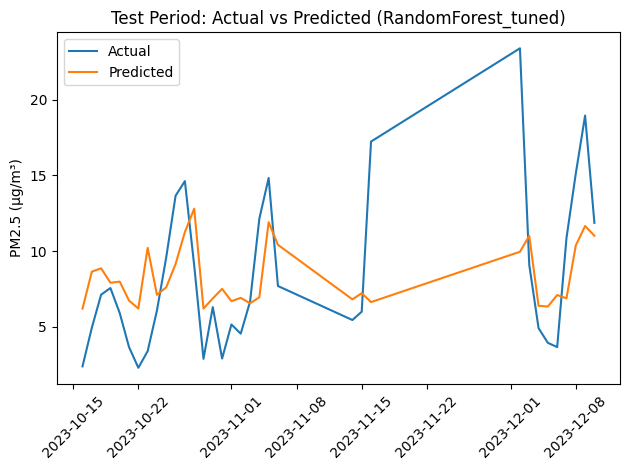

In [19]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

test_dates = df_ml.iloc[split_idx:]["date"].reset_index(drop=True)

plt.figure()
plt.plot(test_dates, y_test.reset_index(drop=True), label="Actual")
plt.plot(test_dates, y_pred, label="Predicted")
plt.xticks(rotation=45)
plt.ylabel("PM2.5 (µg/m³)")
plt.title(f"Test Period: Actual vs Predicted ({best_name})")
plt.legend()
plt.tight_layout()
plt.show()

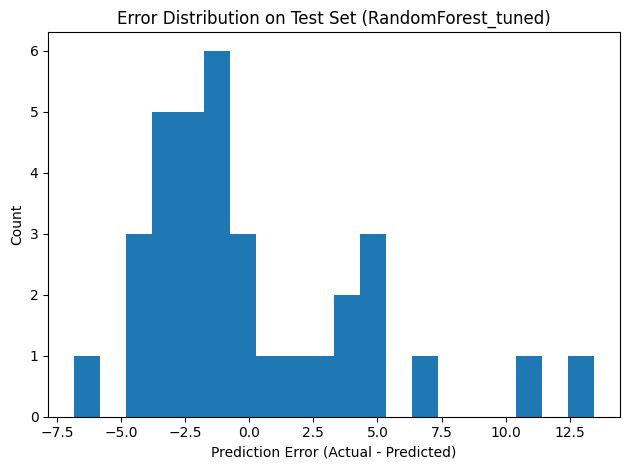

Test MAE: 3.4185988403516148
Test RMSE: 4.384422987770253
Test R2: 0.2832027695197521


In [20]:
errors = y_test.values - y_pred

plt.figure()
plt.hist(errors, bins=20)
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Count")
plt.title(f"Error Distribution on Test Set ({best_name})")
plt.tight_layout()
plt.show()

print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Test R2:", r2_score(y_test, y_pred))

## 9. Feature Importance / Interpretability

- For tree models: built-in feature importances.
- For linear models: coefficients.
- Use permutation importance on the test set for a model-agnostic view.

In [21]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# ensure fitted
best_model.fit(X_train, y_train)

# permutation importance is computed w.r.t. ORIGINAL input columns
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

feature_names = list(X_test.columns)

imp = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

imp.head(15)

,feature,importance_mean,importance_std
11,pm25_lag1,4.725372e-01,1.262555e-01
1,wind_speed_mean,7.282597e-02,3.609397e-02
0,temp_mean,1.240977e-02,1.944744e-02
12,traffic_lag1,9.342305e-03,1.072037e-02
10,doy_cos,1.509765e-03,9.243000e-04
8,dayofyear,8.326673e-17,1.209837e-16
7,month,4.440892e-17,9.550500e-17
9,doy_sin,-7.882857e-05,4.897792e-04
6,traffic_level,-1.111877e-04,3.661568e-04
2,precip_mm,-2.381935e-03,2.423986e-03


## 10. Phase 3 Summary

- Implemented multiple ML models for PM2.5 prediction (baseline + linear + tree-based).
- Used an 80/20 time-based split and time-series cross-validation for tuning.
- Best model selected by lowest test RMSE: **RandomForest_tuned**.
- Test metrics: **MAE = 3.419**, **RMSE = 4.384**, **R² = 0.283**.
- Computed model-agnostic permutation importances on the held-out test set.
